# Ratnapark Air Quality — Exploratory Data Analysis

This notebook performs exploratory data analysis on the extracted
Ratnapark air-quality datasets.

The analysis focuses on:

- Dataset structure
- Date coverage
- Missing values
- Year-wise and month-wise data availability
- Descriptive statistics
- Distribution of pollutant concentrations
- Comparison between years
- Identification of potential outliers

No missing values are modified during the initial EDA.
A missing-value treatment strategy will be selected only after
understanding the amount and pattern of missing data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
df_2016_2020 = pd.read_csv(
    "../data/processed/ratnapark/ratnapark_2016_2020_raw.csv"
)

df_2024 = pd.read_csv(
    "../data/processed/ratnapark/ratnapark_2024_raw.csv"
)

df_2025 = pd.read_csv(
    "../data/processed/ratnapark/ratnapark_2025_raw.csv"
)

In [4]:
print("2016–2020:", df_2016_2020.shape)
print("2024:", df_2024.shape)
print("2025:", df_2025.shape)

2016–2020: (43824, 6)
2024: (366, 4)
2025: (365, 4)


In [5]:
display(df_2016_2020.head())
display(df_2024.head())
display(df_2025.head())

,date,pm1,year,pm2_5,pm10,tsp
0,2016-01-01,NaN,2016,NaN,NaN,NaN
1,2016-01-01,NaN,2016,NaN,NaN,NaN
2,2016-01-01,NaN,2016,NaN,NaN,NaN
3,2016-01-01,NaN,2016,NaN,NaN,NaN
4,2016-01-01,NaN,2016,NaN,NaN,NaN


,date,PM2.5,PM10,TSP
0,2024-01-01,90.78,143.77,NaN
1,2024-01-02,67.56,115.42,NaN
2,2024-01-03,75.89,124.43,NaN
3,2024-01-04,71.93,124.66,NaN
4,2024-01-05,71.62,120.35,NaN


,date,PM2.5,PM10,TSP
0,2025-01-01,84.27,107.60,144.71
1,2025-01-02,75.46,98.92,139.66
2,2025-01-03,76.43,103.15,137.18
3,2025-01-04,77.29,101.31,130.65
4,2025-01-05,96.78,126.56,152.27


In [6]:
print("2016–2020")
display(df_2016_2020.isna().sum())

print("\n2024")
display(df_2024.isna().sum())

print("\n2025")
display(df_2025.isna().sum())

2016–2020


date         0
pm1      12438
year         0
pm2_5    12488
pm10     12588
tsp      12336
dtype: int64


2024


date       0
PM2.5     98
PM10      97
TSP      229
dtype: int64


2025


date      0
PM2.5    59
PM10     59
TSP      59
dtype: int64

In [7]:
def missing_summary(df):
    summary = pd.DataFrame({
        "missing": df.isna().sum(),
        "total": len(df),
        "missing_percent": df.isna().mean() * 100
    })

    return summary


display(missing_summary(df_2016_2020))

,missing,total,missing_percent
date,0,43824,0.00
pm1,12438,43824,28.38
year,0,43824,0.00
pm2_5,12488,43824,28.50
pm10,12588,43824,28.72
tsp,12336,43824,28.15


In [8]:
def missing_summary(df):
    summary = pd.DataFrame({
        "missing": df.isna().sum(),
        "total": len(df),
        "missing_percent": df.isna().mean() * 100
    })

    return summary


display(missing_summary(df_2024))

,missing,total,missing_percent
date,0,366,0.00
PM2.5,98,366,26.78
PM10,97,366,26.50
TSP,229,366,62.57


In [9]:
def missing_summary(df):
    summary = pd.DataFrame({
        "missing": df.isna().sum(),
        "total": len(df),
        "missing_percent": df.isna().mean() * 100
    })

    return summary


display(missing_summary(df_2025))

,missing,total,missing_percent
date,0,365,0.00
PM2.5,59,365,16.16
PM10,59,365,16.16
TSP,59,365,16.16


### here we can see in 2025 missing values are same , so maybe missing values are on same day so lets check that by seeing any of them missing and all of them missing are same or not

In [15]:
df_2025[["PM2.5", "PM10", "TSP"]].isna().all(axis=1).sum()

np.int64(59)

In [14]:
df_2025[["PM2.5", "PM10", "TSP"]].isna().any(axis=1).sum()

np.int64(59)

In [12]:
pollutants = ["pm1", "pm2_5", "pm10", "tsp"]
print(
    "All pollutants missing:",
    df_2016_2020[pollutants]
    .isna()
    .all(axis=1)
    .sum()
)

print(
    "At least one pollutant missing:",
    df_2016_2020[pollutants]
    .isna()
    .any(axis=1)
    .sum()
)

All pollutants missing: 12286
At least one pollutant missing: 12732


In [18]:
pollutants_2024 = ["PM2.5", "PM10", "TSP"]

print(
    "All pollutants missing:",
    df_2024[pollutants_2024]
    .isna()
    .all(axis=1)
    .sum()
)

print(
    "At least one pollutant missing:",
    df_2024[pollutants_2024]
    .isna()
    .any(axis=1)
    .sum()
)

All pollutants missing: 97
At least one pollutant missing: 229


In [19]:
pollutants_2024 = ["PM2.5", "PM10"]

print(
    "All pollutants missing:",
    df_2024[pollutants_2024]
    .isna()
    .all(axis=1)
    .sum()
)

print(
    "At least one pollutant missing:",
    df_2024[pollutants_2024]
    .isna()
    .any(axis=1)
    .sum()
)

All pollutants missing: 97
At least one pollutant missing: 98


## Let's work on month based missing data checking 

In [38]:
df_2016_2020["date"] = pd.to_datetime(df_2016_2020["date"])
df_2024["date"] = pd.to_datetime(df_2024["date"])
df_2025["date"] = pd.to_datetime(df_2025["date"])

In [39]:
df_old = df_2016_2020[
    ["date", "pm1", "pm2_5", "pm10", "tsp"]
].copy()

df_old = df_old.rename(columns={
    "pm1": "PM1",
    "pm2_5": "PM2.5",
    "pm10": "PM10",
    "tsp": "TSP"
})

df_2024_common = df_2024[
    ["date", "PM2.5", "PM10", "TSP"]
].copy()

df_2024_common["PM1"] = np.nan

df_2024_common = df_2024_common[
    ["date", "PM1", "PM2.5", "PM10", "TSP"]
]

df_2025_common = df_2025[
    ["date", "PM2.5", "PM10", "TSP"]
].copy()

df_2025_common["PM1"] = np.nan

df_2025_common = df_2025_common[
    ["date", "PM1", "PM2.5", "PM10", "TSP"]
]

In [40]:
df_all = pd.concat(
    [
        df_old,
        df_2024_common,
        df_2025_common
    ],
    ignore_index=True
)

df_all["year"] = df_all["date"].dt.year
df_all["month"] = df_all["date"].dt.month

In [41]:
pollutants = ["PM1", "PM2.5", "PM10", "TSP"]

monthly_missing = (
    df_all
    .groupby(["year", "month"])[pollutants]
    .apply(lambda x: x.isna().mean() * 100)
    .reset_index()
)

display(monthly_missing)

,year,month,PM1,PM2.5,PM10,TSP
0,2016,1,100.00,100.00,100.00,100.00
1,2016,2,100.00,100.00,100.00,100.00
2,2016,3,100.00,100.00,100.00,100.00
3,2016,4,100.00,100.00,100.00,100.00
4,2016,5,100.00,100.00,100.00,100.00
...,...,...,...,...,...,...
79,2025,8,100.00,0.00,0.00,0.00
80,2025,9,100.00,46.67,46.67,46.67
81,2025,10,100.00,100.00,100.00,100.00
82,2025,11,100.00,40.00,40.00,40.00


### PM1 Missing 

In [43]:
pm1_monthly = monthly_missing.pivot(
    index="year",
    columns="month",
    values="PM1"
)

pm1_monthly.columns = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

display(pm1_monthly.round(2))

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2016,100.00,100.00,100.00,100.00,100.00,100.00,100.00,87.10,46.67,0.00,0.00,2.42
2017,12.90,7.14,29.03,3.33,3.23,0.00,0.00,0.00,0.00,0.00,36.67,3.23
2018,0.00,0.00,18.55,60.00,70.97,0.00,16.13,0.00,0.00,0.00,0.00,0.00
2019,0.00,7.14,0.00,23.33,29.03,10.00,61.29,0.00,0.00,16.13,0.00,0.00
2020,0.00,0.00,47.58,0.00,0.00,0.00,0.00,45.16,100.00,100.00,100.00,63.33
2024,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2025,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00


### PM2.5 missing

In [44]:
pm25_monthly = monthly_missing.pivot(
    index="year",
    columns="month",
    values="PM2.5"
)

pm25_monthly.columns = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

display(pm25_monthly.round(2))

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2016,100.00,100.00,100.00,100.00,100.00,100.00,100.00,87.10,46.67,0.00,0.00,2.15
2017,12.90,7.14,29.03,3.33,3.23,0.00,0.00,0.00,0.00,0.00,36.67,3.23
2018,0.00,0.00,21.51,60.00,70.97,0.00,16.13,0.00,0.00,0.00,0.00,0.00
2019,0.00,7.14,0.00,23.33,29.03,10.00,61.29,0.00,0.00,16.13,0.00,0.00
2020,0.00,0.00,51.61,0.00,0.00,0.00,0.00,45.16,100.00,100.00,100.00,63.33
2024,0.00,10.34,3.23,0.00,22.58,0.00,100.00,100.00,53.33,0.00,30.00,0.00
2025,0.00,0.00,6.45,0.00,0.00,0.00,0.00,0.00,46.67,100.00,40.00,0.00


### PM10 missing

In [45]:
pm10_monthly = monthly_missing.pivot(
    index="year",
    columns="month",
    values="PM10"
)

pm10_monthly.columns = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

display(pm10_monthly.round(2))

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2016,100.00,100.00,100.00,100.00,100.00,100.00,100.00,87.10,46.67,0.00,0.00,1.61
2017,12.90,7.14,29.03,3.33,3.23,0.00,0.00,0.00,0.00,0.00,36.67,3.23
2018,0.00,0.00,27.42,60.00,70.97,0.00,16.13,0.00,0.00,0.00,0.00,0.00
2019,0.00,7.14,0.00,23.33,29.03,10.00,61.29,0.00,0.00,16.13,0.00,0.00
2020,0.00,0.00,59.68,0.00,0.00,0.00,0.00,45.16,100.00,100.00,100.00,63.33
2024,0.00,6.90,3.23,0.00,22.58,0.00,100.00,100.00,53.33,0.00,30.00,0.00
2025,0.00,0.00,6.45,0.00,0.00,0.00,0.00,0.00,46.67,100.00,40.00,0.00


### TSP missing

In [46]:
tsp_monthly = monthly_missing.pivot(
    index="year",
    columns="month",
    values="TSP"
)

tsp_monthly.columns = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

display(tsp_monthly.round(2))

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2016,100.00,100.00,100.00,100.00,100.00,100.00,100.00,87.10,46.67,0.00,0.00,3.23
2017,12.90,7.14,29.03,3.33,3.23,0.00,0.00,0.00,0.00,0.00,36.67,3.23
2018,0.00,0.00,9.68,60.00,70.97,0.00,16.13,0.00,0.00,0.00,0.00,0.00
2019,0.00,7.14,0.00,23.33,29.03,10.00,61.29,0.00,0.00,16.13,0.00,0.00
2020,0.00,0.00,41.94,0.00,0.00,0.00,0.00,45.16,100.00,100.00,100.00,63.33
2024,100.00,100.00,100.00,100.00,67.74,0.00,100.00,100.00,53.33,0.00,30.00,0.00
2025,0.00,0.00,6.45,0.00,0.00,0.00,0.00,0.00,46.67,100.00,40.00,0.00


In [47]:
def plot_missing_heatmap(table, title):
    plt.figure(figsize=(14, 5))

    plt.imshow(
        table,
        aspect="auto"
    )

    plt.xticks(
        range(12),
        table.columns
    )

    plt.yticks(
        range(len(table)),
        table.index
    )

    plt.xlabel("Month")
    plt.ylabel("Year")
    plt.title(title)

    plt.colorbar(label="Missing (%)")

    plt.show()

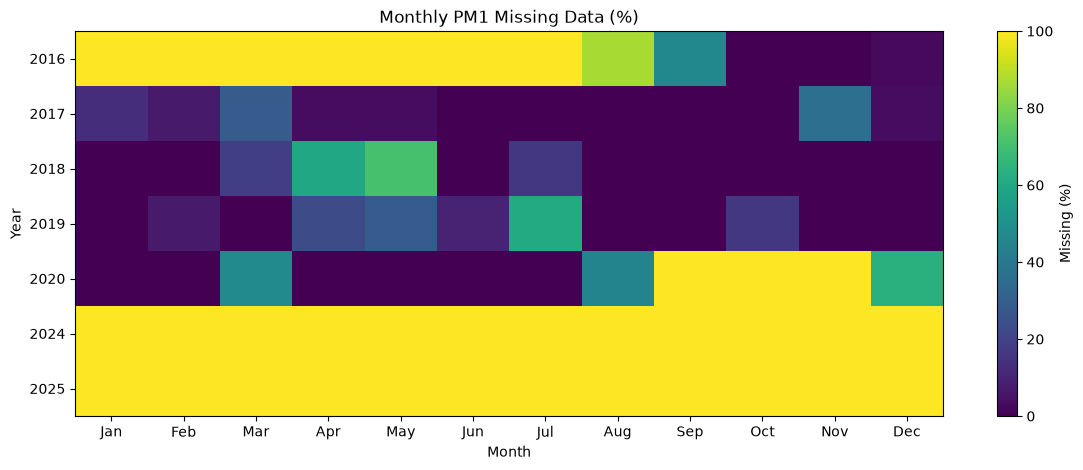

In [48]:
plot_missing_heatmap(
    pm1_monthly,
    "Monthly PM1 Missing Data (%)"
)

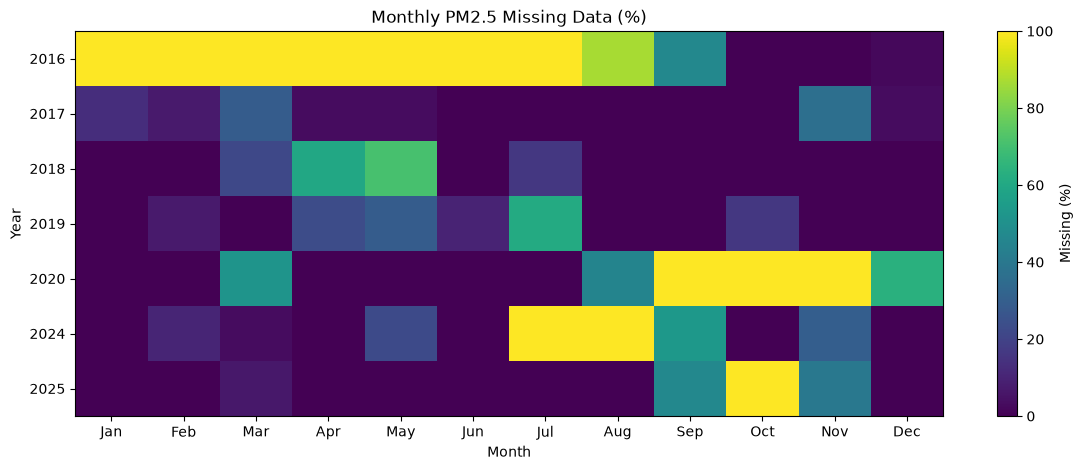

In [49]:
plot_missing_heatmap(
    pm25_monthly,
    "Monthly PM2.5 Missing Data (%)"
)

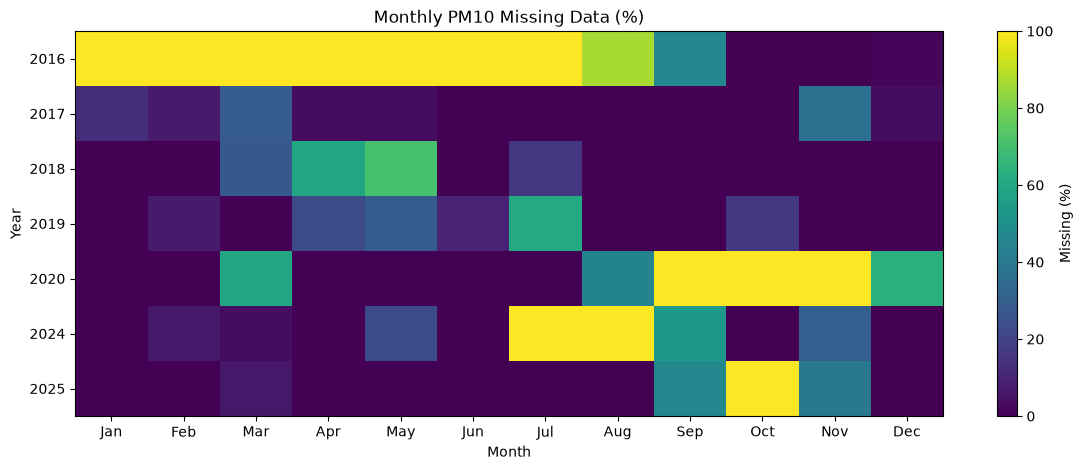

In [50]:
plot_missing_heatmap(
    pm10_monthly,
    "Monthly PM10 Missing Data (%)"
)

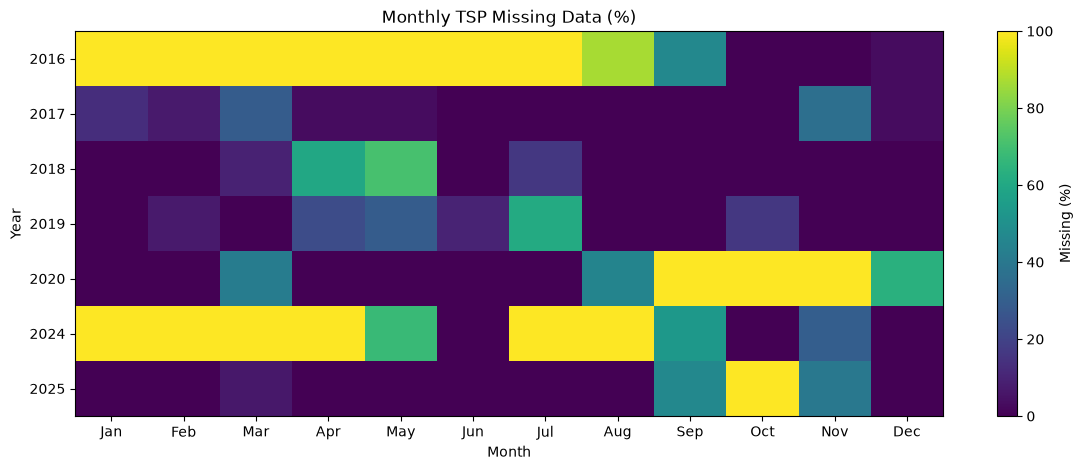

In [51]:
plot_missing_heatmap(
    tsp_monthly,
    "Monthly TSP Missing Data (%)"
)

## Pollutants Used

This project focuses on **PM2.5 and PM10** for prediction.

- **PM2.5** is selected as the primary prediction target because it is an important particulate pollutant for AQI assessment.
- **PM10** is included because it is consistently available alongside PM2.5 across the historical and recent datasets.
- **PM1** is excluded because it is completely unavailable in the 2024 and 2025 historical datasets.
- **TSP** is excluded because it is not available in the real-time data source used for forecasting and has substantial missing data in the historical datasets.

In [52]:
corr = df_2016_2020[
    ["pm1", "pm2_5", "pm10"]
].corr()

display(corr.round(3))

,pm1,pm2_5,pm10
pm1,1.00,0.43,0.52
pm2_5,0.43,1.00,0.59
pm10,0.52,0.59,1.00


In [53]:
df_corr = df_2016_2020[
    ["pm1", "pm2_5", "pm10"]
].dropna()

df_corr["pm2_5_minus_pm1"] = (
    df_corr["pm2_5"] - df_corr["pm1"]
)

df_corr["pm10_minus_pm1"] = (
    df_corr["pm10"] - df_corr["pm1"]
)

display(
    df_corr[
        ["pm2_5_minus_pm1", "pm10_minus_pm1"]
    ].describe()
)

,pm2_5_minus_pm1,pm10_minus_pm1
count,31093.00,31093.00
mean,15.81,43.15
std,112.81,113.22
min,-1188.52,-765.72
25%,0.00,0.00
50%,0.00,6.53
75%,33.46,69.70
max,1240.88,1240.88


In [54]:
df_corr["pm1_pm2_5_ratio"] = (
    df_corr["pm1"] / df_corr["pm2_5"]
)

display(
    df_corr["pm1_pm2_5_ratio"].describe()
)

count   31093.00
mean        1.19
std         1.45
min         0.02
25%         0.55
50%         1.00
75%         1.00
max        28.14
Name: pm1_pm2_5_ratio, dtype: float64

In [55]:
for year in sorted(df_2016_2020["year"].unique()):
    temp = df_2016_2020[
        df_2016_2020["year"] == year
    ][["pm1", "pm2_5", "pm10"]].dropna()

    print(f"\n{year}")
    print(temp.corr().round(3))


2016
       pm1  pm2_5  pm10
pm1   1.00   0.16  0.22
pm2_5 0.16   1.00  0.27
pm10  0.22   0.27  1.00

2017
       pm1  pm2_5  pm10
pm1   1.00   0.35  0.45
pm2_5 0.35   1.00  0.53
pm10  0.45   0.53  1.00

2018
       pm1  pm2_5  pm10
pm1   1.00   0.39  0.47
pm2_5 0.39   1.00  0.55
pm10  0.47   0.55  1.00

2019
       pm1  pm2_5  pm10
pm1   1.00   0.65  0.72
pm2_5 0.65   1.00  0.77
pm10  0.72   0.77  1.00

2020
       pm1  pm2_5  pm10
pm1   1.00   0.68  0.73
pm2_5 0.68   1.00  0.76
pm10  0.73   0.76  1.00
